# CSV content analysis

- number of URLs in the content
- number of dates in the content
- number of numeric values in the content
- the 100 most frequent words in the content
- a plot of the 10,000 most frequent words

In [6]:
from pathlib import Path
import re
from collections import Counter
import time

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## 1. Set the CSV path
Change the path below so it points to your CSV file.

In [7]:
CSV_PATH = Path(r"C:\Users\jespe\GDS eksamen\Data\NoteBooks\news_cleaned_2018_02_13.csv")
CONTENT_COLUMN = "content"
ENCODING = "utf-8"
CHUNK_SIZE = 500000  # Process 500K rows at a time

## 2. Validate CSV header
This checks that the file is readable and that the target column exists, without loading the full dataset.

In [8]:
header_df = pd.read_csv(CSV_PATH, encoding=ENCODING, nrows=0)

if CONTENT_COLUMN not in header_df.columns:
    raise ValueError(
        f"Column '{CONTENT_COLUMN}' was not found. Available columns: {list(header_df.columns)}"
    )

print(f"CSV is readable: {CSV_PATH}")
print(f"Detected columns: {list(header_df.columns)}")
print(f"Using chunk size: {CHUNK_SIZE:,} rows")

CSV is readable: C:\Users\jespe\GDS eksamen\Data\NoteBooks\news_cleaned_2018_02_13.csv
Detected columns: ['Unnamed: 0', 'id', 'domain', 'type', 'url', 'content', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary', 'source']
Using chunk size: 500,000 rows


## 3. Regex patterns

These patterns are practical defaults:

- **URL pattern**: matches `http://`, `https://`, and `www.`
- **Date pattern**: matches common formats such as:
  - `2024-03-11`
  - `11-03-2024`
  - `11/03/2024`
  - `March 11, 2024`
- **Numeric pattern**: matches integers, decimals, and signed values

In [9]:
URL_PATTERN = re.compile(
    r"\b(?:https?://|www\.)[^\s<>'\"()]+",
    flags=re.IGNORECASE
)

DATE_PATTERN = re.compile(
    r"\b(?:"
    r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}"
    r"|"
    r"\d{4}[/-]\d{1,2}[/-]\d{1,2}"
    r"|"
    r"(?:jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
    r"[a-z]*\s+\d{1,2},?\s+\d{2,4}"
    r")\b",
    flags=re.IGNORECASE
)

NUMERIC_PATTERN = re.compile(
    r"(?<!\w)[+-]?(?:\d+(?:[.,]\d+)?)(?!\w)"
)

WORD_PATTERN = re.compile(r"\b[a-zA-ZÀ-ÿ']+\b")

## 4. Stream through CSV and aggregate counts
This processes the file chunk-by-chunk to avoid loading the full dataset into memory.

In [10]:
start_time = time.time()
print(f"Starting DuckDB processing at {time.strftime('%H:%M:%S')}\n")

# Create DuckDB connection with memory limit
con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute("SET threads=8")

print("Step 1: Counting total rows...")
scan_start = time.time()

# Query directly without creating table to save memory
total_rows = con.execute(f"""
    SELECT COUNT(*) 
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
""").fetchone()[0]

print(f"  ✓ Total rows: {total_rows:,} (scanned in {time.time() - scan_start:.1f}s)\n")

# Step 2: Count URLs, dates, and numeric values - stream without loading into table
print("Step 2: Counting URLs, dates, and numeric values...")
regex_start = time.time()

url_pattern = r'https?://[^\s<>''\"()]+|www\.[^\s<>''\"()]+' 
date_pattern = r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}'
numeric_pattern = r'\b\d+\.?\d*\b'

# Stream and count in one pass
result = con.execute(f"""
    SELECT 
        SUM(LENGTH(regexp_extract_all(content, '{url_pattern}', 0))) as total_urls,
        SUM(LENGTH(regexp_extract_all(content, '{date_pattern}', 0))) as total_dates,
        SUM(LENGTH(regexp_extract_all(content, '{numeric_pattern}', 0))) as total_numeric
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
""").fetchone()

total_urls = result[0] if result[0] else 0
total_dates = result[1] if result[1] else 0
total_numeric = result[2] if result[2] else 0

print(f"  ✓ Done in {time.time() - regex_start:.1f}s")
print(f"    - URLs: {total_urls:,}")
print(f"    - Dates: {total_dates:,}")
print(f"    - Numeric: {total_numeric:,}\n")

# Step 3: Extract and count words in chunks
print("Step 3: Extracting and counting words...")
print("  (Processing in chunks to manage memory...)")
word_start = time.time()

word_counts = Counter()
chunk_size = 500000

for offset in range(0, total_rows, chunk_size):
    chunk_start_time = time.time()
    
    # Stream words from CSV chunk
    words_df = con.execute(f"""
        SELECT regexp_extract_all(LOWER(content), '[a-zA-ZÀ-ÿ'']+', 0) as words
        FROM read_csv_auto('{str(CSV_PATH)}', 
                           sample_size=50000,
                           parallel=true,
                           strict_mode=false,
                           ignore_errors=true)
        WHERE content IS NOT NULL
        LIMIT {chunk_size} OFFSET {offset}
    """).fetchdf()
    
    # Count words - handle arrays properly
    for word_list in words_df['words']:
        if word_list is not None and len(word_list) > 0:
            word_counts.update(word_list)
    
    processed = min(offset + chunk_size, total_rows)
    elapsed = time.time() - word_start
    remaining = (elapsed / processed) * (total_rows - processed) / 60 if processed > 0 else 0
    
    print(f"    - Processed {processed:,}/{total_rows:,} rows ({processed/total_rows*100:.1f}%) "
          f"in {elapsed:.1f}s - Est. remaining: {remaining:.1f} min")
    
    del words_df

print(f"  ✓ Word counting complete in {time.time() - word_start:.1f}s\n")

# Step 4: Create preview
print("Step 4: Creating preview...")
preview_df = con.execute(f"""
    SELECT 
        content,
        LENGTH(regexp_extract_all(content, '{url_pattern}', 0)) as url_count,
        LENGTH(regexp_extract_all(content, '{date_pattern}', 0)) as date_count,
        LENGTH(regexp_extract_all(content, '{numeric_pattern}', 0)) as numeric_count
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
    LIMIT 5
""").fetchdf()

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"PROCESSING COMPLETE!")
print(f"{'='*60}")
print(f"Total rows processed: {total_rows:,}")
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Average speed: {total_rows/total_time:.0f} rows/second")
print(f"{'='*60}\n")

# Close connection
con.close()

preview_df

Starting DuckDB processing at 15:02:29

Step 1: Counting total rows...


<>:29: SyntaxWarning: invalid escape sequence '\.'
<>:29: SyntaxWarning: invalid escape sequence '\.'
C:\Users\jespe\AppData\Local\Temp\ipykernel_9108\1108022216.py:29: SyntaxWarning: invalid escape sequence '\.'
  url_pattern = r'https?://[^\s<>''\"()]+|www\.[^\s<>''\"()]+'


  ✓ Total rows: 8,529,477 (scanned in 26.6s)

Step 2: Counting URLs, dates, and numeric values...
  ✓ Done in 65.9s
    - URLs: 2,285,422
    - Dates: 696,215
    - Numeric: 79,323,243

Step 3: Extracting and counting words...
  (Processing in chunks to manage memory...)
    - Processed 500,000/8,529,477 rows (5.9%) in 196.5s - Est. remaining: 52.6 min
    - Processed 1,000,000/8,529,477 rows (11.7%) in 609.0s - Est. remaining: 76.4 min
    - Processed 1,500,000/8,529,477 rows (17.6%) in 972.4s - Est. remaining: 75.9 min
    - Processed 2,000,000/8,529,477 rows (23.4%) in 1445.2s - Est. remaining: 78.6 min
    - Processed 2,500,000/8,529,477 rows (29.3%) in 2180.1s - Est. remaining: 87.6 min
    - Processed 3,000,000/8,529,477 rows (35.2%) in 2964.2s - Est. remaining: 91.1 min
    - Processed 3,500,000/8,529,477 rows (41.0%) in 3677.9s - Est. remaining: 88.1 min
    - Processed 4,000,000/8,529,477 rows (46.9%) in 4364.7s - Est. remaining: 82.4 min
    - Processed 4,500,000/8,529,477 ro

,content,url_count,date_count,numeric_count
0,"Life is an illusion, at least on a quantum lev...",0,0,1
1,"Unfortunately, he hasn’t yet attacked her for ...",0,0,0
2,The Los Angeles Police Department has been den...,0,0,1
3,The White House has decided to quietly withdra...,0,0,0
4,“The time has come to cut off the tongues of t...,0,0,0


## 5. Show total counts for the whole dataset

In [11]:
print(f"Total URLs found: {total_urls:,}")
print(f"Total dates found: {total_dates:,}")
print(f"Total numeric values found: {total_numeric:,}")

Total URLs found: 2,285,422
Total dates found: 696,215
Total numeric values found: 79,323,243


## 6. Find the 100 most frequent words in the content

Word frequencies were aggregated during chunked processing above.

In [12]:
top_100_words = word_counts.most_common(100)
top_100_df = pd.DataFrame(top_100_words, columns=["word", "count"])

top_100_df

,word,count
0,the,224561604
1,to,108430614
2,of,107081534
3,and,98657259
4,a,86002693
...,...,...
95,trump,4084417
96,any,3934880
97,obama,3905724
98,world,3883279


## 7. Plot the frequency of the 10,000 most frequent words

Because frequencies usually drop very quickly, the y-axis is shown on a logarithmic scale.

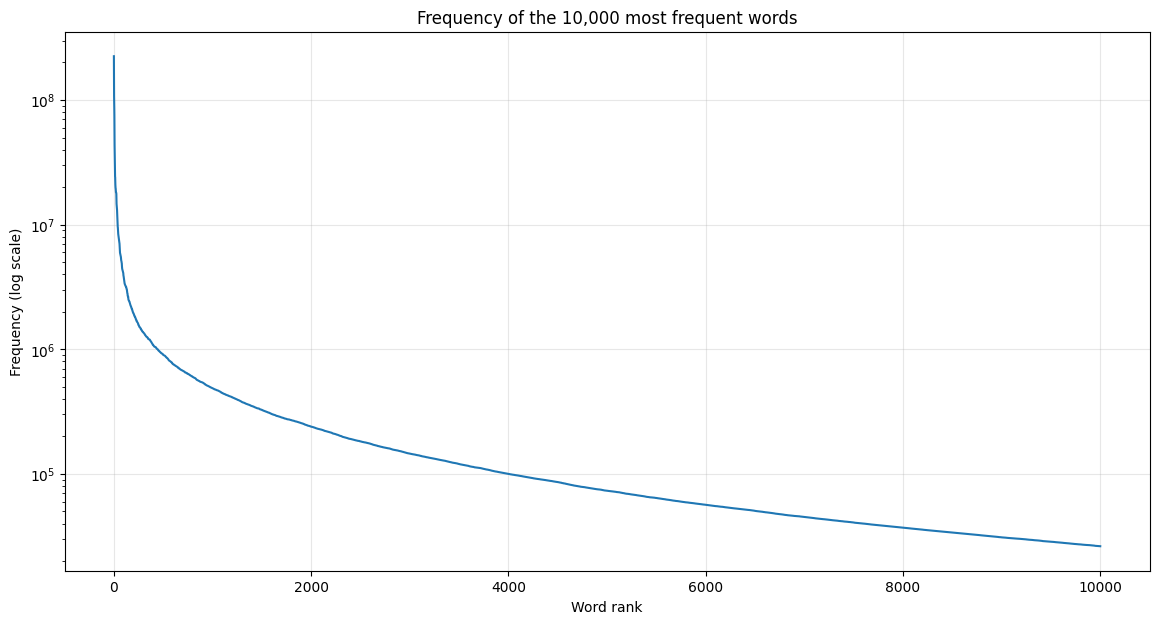

In [13]:
top_10000 = word_counts.most_common(10000)

freq_values = [count for _, count in top_10000]
ranks = range(1, len(freq_values) + 1)

plt.figure(figsize=(14, 7))
plt.plot(ranks, freq_values)
plt.yscale("log")
plt.xlabel("Word rank")
plt.ylabel("Frequency (log scale)")
plt.title("Frequency of the 10,000 most frequent words")
plt.grid(True, alpha=0.3)
plt.show()